In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read Data

In [3]:
my_data = pd.read_csv('Data/Final_Data_Set.csv')
my_data['Homeless_Per_Capita'] = my_data['Overall_Homeless'] / my_data["Total_Population"]
my_data

,Group_Number,year,Overall_Homeless,Unsheltered_Homeless,Sheltered_Total_Homeless,Overall_Homeless_Individuals,Overall_Homeless_People_in_Families,Beds,Total_Population,Central_Tendency_Rent,Central_Tendency_Income,Poverty_Rate,Vacancy_Rate,Renter_Occupied_Rate,Rent_Burdened_Rate,Unemployment_Rate,Homeless_Per_Capita
0,1.0,2009,377.0,114.0,263.0,305.0,72.0,345.0,374216.0,542.527835,40785.6,0.165593,0.089301,0.318287,0.458936,0.076226,0.001007
1,1.0,2010,444.0,150.0,294.0,376.0,68.0,384.0,381477.0,568.151431,42284.8,0.168996,0.090553,0.313720,0.465746,0.079653,0.001164
2,1.0,2011,433.0,146.0,287.0,333.0,100.0,375.0,383939.0,581.080426,42635.4,0.173827,0.092315,0.314383,0.482038,0.088622,0.001128
3,1.0,2012,487.0,144.0,343.0,383.0,104.0,413.0,385379.0,605.302942,43242.2,0.177680,0.085862,0.320167,0.496161,0.090039,0.001264
4,1.0,2013,515.0,116.0,399.0,446.0,69.0,458.0,385614.0,646.035799,42300.2,0.184772,0.072895,0.330066,0.491747,0.093317,0.001336
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4914,347.0,2019,568186.0,211502.0,356684.0,396421.0,171765.0,353.0,235300.0,666.524681,48388.2,0.166881,0.053190,0.275850,0.399389,0.056913,2.414730
4915,347.0,2020,580746.0,226278.0,354468.0,409134.0,171612.0,115.0,235382.0,652.069862,51598.0,0.151359,0.047918,0.275939,0.379556,0.049519,2.467249
4916,347.0,2021,381491.0,55124.0,326367.0,237289.0,137564.0,323.0,233169.0,707.810225,54169.8,0.150172,0.044699,0.269815,0.377205,0.054654,1.636114
4917,347.0,2022,583026.0,234146.0,348880.0,421952.0,161074.0,291.0,232302.0,786.178031,59067.4,0.141108,0.039093,0.267547,0.368974,0.050359,2.509776


# Remove Outliers

In [4]:

iqr_factor = 3

# Select numeric columns
df_numeric = my_data.select_dtypes(include=[np.number])

# Calculate IQR
Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)
IQR = Q3 - Q1

# Calculate the bounds
lower_bound = Q1 - iqr_factor * IQR
upper_bound = Q3 + iqr_factor * IQR

# Create a boolean mask to identify non-outlier rows
# A row is NOT an outlier if ALL its numerical values are within the fences.
# We check if each value is >= lower_bound AND <= upper_bound.
# The .all(axis=1) checks if ALL columns for that ROW satisfy the condition.
non_outlier_mask = (
    (df_numeric >= lower_bound) & (df_numeric <= upper_bound)
).all(axis=1)

# Filter the original DataFrame using the mask
df_cleaned = my_data[non_outlier_mask]

Group_Number                          -4.390000e+02
year                                   1.988000e+03
Overall_Homeless                      -3.171500e+03
Unsheltered_Homeless                  -1.216000e+03
Sheltered_Total_Homeless              -1.904500e+03
Overall_Homeless_Individuals          -2.213000e+03
Overall_Homeless_People_in_Families   -9.510000e+02
Beds                                  -2.097000e+03
Total_Population                      -1.733016e+06
Central_Tendency_Rent                 -1.553507e+02
Central_Tendency_Income               -1.855166e+04
Poverty_Rate                          -6.186538e-02
Vacancy_Rate                          -5.417576e-02
Renter_Occupied_Rate                  -5.025109e-03
Rent_Burdened_Rate                     2.177508e-01
Unemployment_Rate                     -4.732916e-02
Homeless_Per_Capita                   -3.165807e-03
dtype: float64


In [9]:
print(my_data.shape)
print(df_cleaned.shape)

(4919, 17)
(3557, 17)


# Histograms of 10 Columns

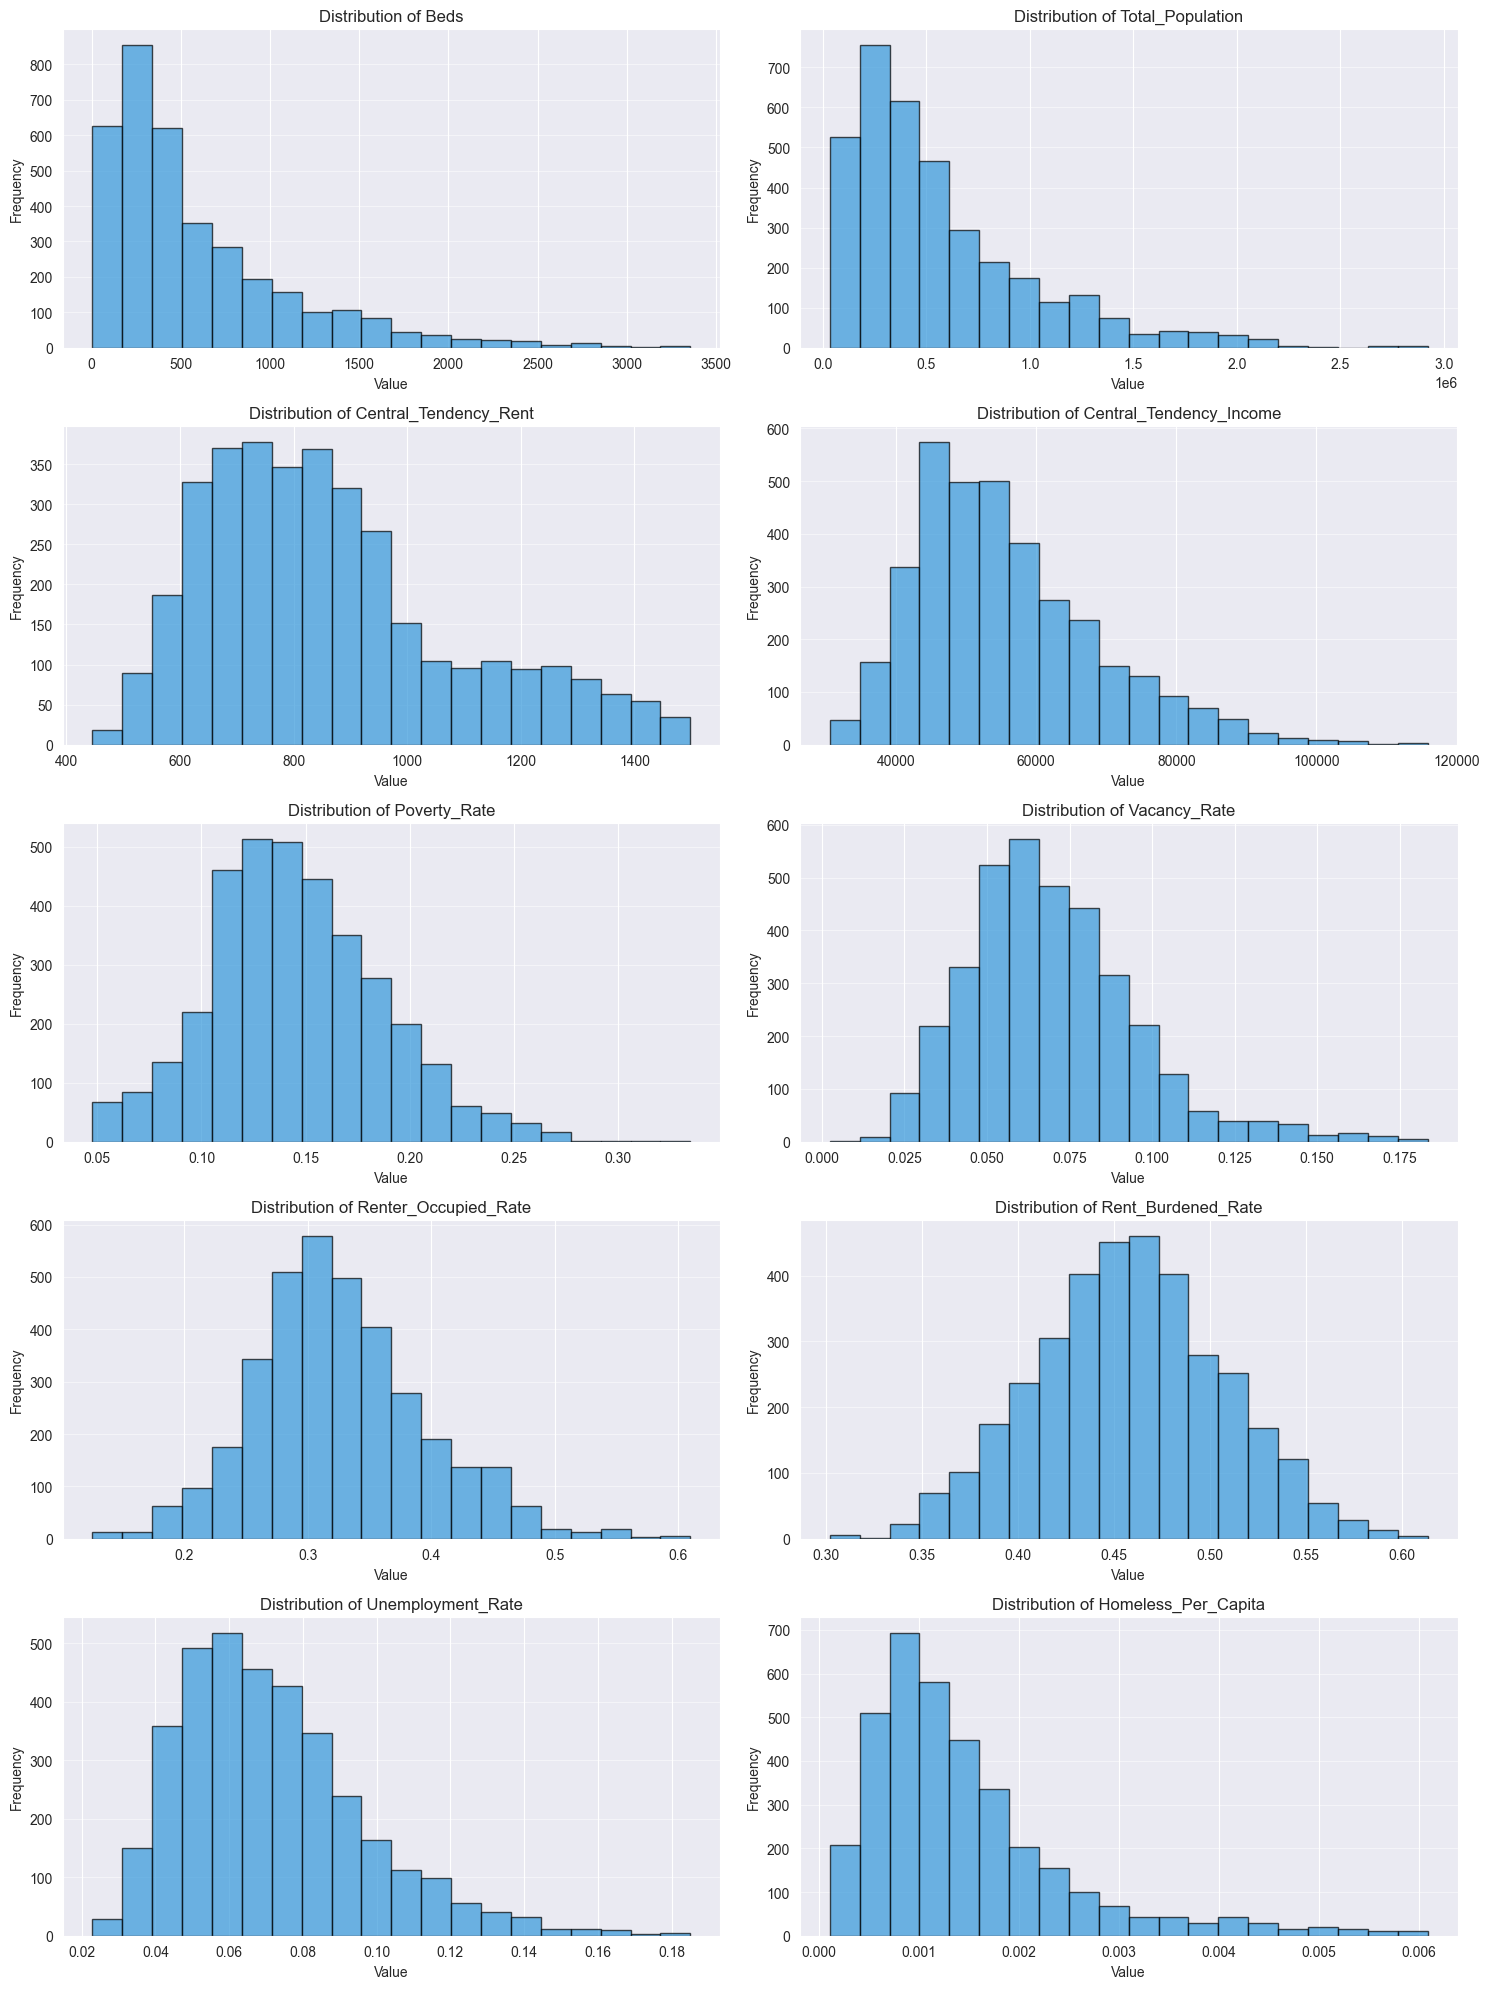

In [6]:
# 5 rows and 2 columns = 10 plots
n_rows = 5
n_cols = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 20))

# Flatten the axes array to iterate through
axes = axes.flatten()

# List of columns to plot
columns_to_plot = ["Beds","Total_Population","Central_Tendency_Rent","Central_Tendency_Income",
                   "Poverty_Rate","Vacancy_Rate","Renter_Occupied_Rate","Rent_Burdened_Rate",
                   "Unemployment_Rate","Homeless_Per_Capita"]

# Loop through columns plotting histograms
for i, col in enumerate(columns_to_plot):
    # --- Plotting the Filtered Data ---
    df_cleaned[col].hist(ax=axes[i], bins=20, edgecolor='black', color='#3498db', alpha=0.7)

    # Customize each subplot
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', alpha=0.5)

# Ensure tight layout to prevent titles and labels from overlapping
plt.tight_layout()

# Display the entire grid
plt.show()

# Boxplots of 10 Columns

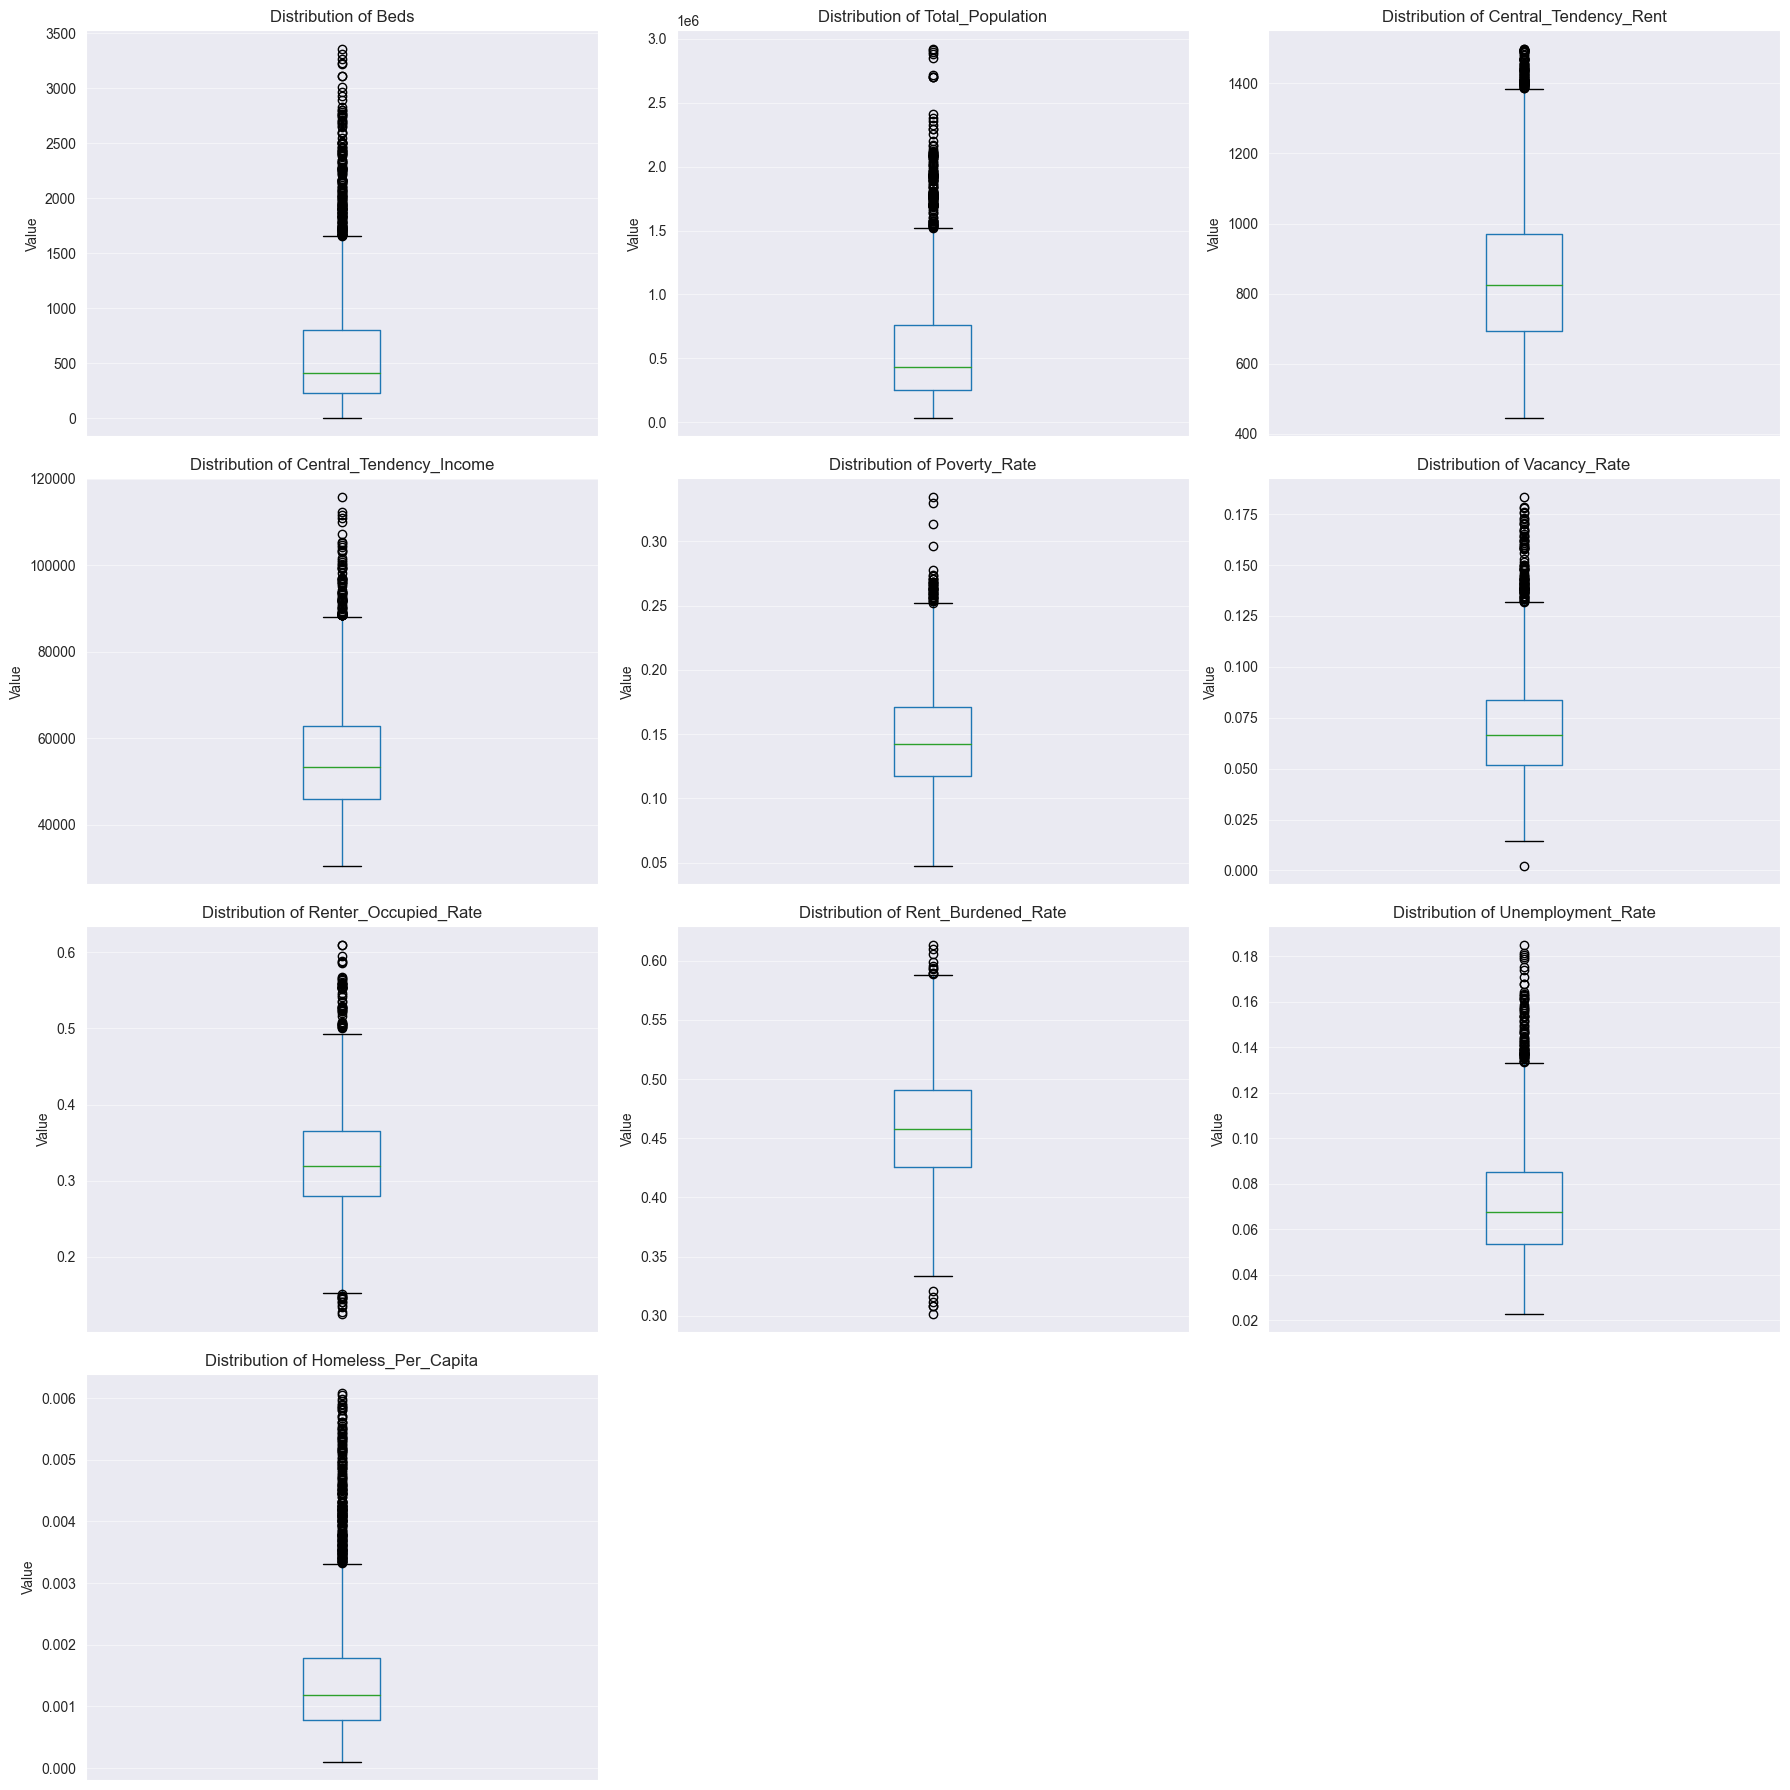

In [11]:
# Define grid: 3x3 for the first nine, and the 10th on the 4th row
n_rows = 4
n_cols = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 18))

# Flatten the axes to loop through it
axes = axes.flatten()
n_plots = 10

# Loop through the columns and plot the boxplots
for i, col in enumerate(columns_to_plot):
    # Use Pandas boxplot()
    df_cleaned.boxplot(
        column=col,
        ax=axes[i]
    )

    # Customize each subplot
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel('') # X-axis has no meaningful label for a single vertical boxplot
    axes[i].set_ylabel('Value') # Y-axis represents the data value
    axes[i].grid(axis='y', alpha=0.5)
    # Remove the default 'Column Name' tick label on the X-axis for a cleaner look
    axes[i].set_xticks([])


# --- 3. Remove Unused Subplots ---
# Delete the extra axes created in the 4x3 grid (positions 10 and 11)
for j in range(n_plots, n_rows * n_cols):
    fig.delaxes(axes[j])

# Ensure tight layout to prevent titles and labels from overlapping
plt.tight_layout()

# Display the entire grid
plt.show()

# Violin Plots of 10 Columns

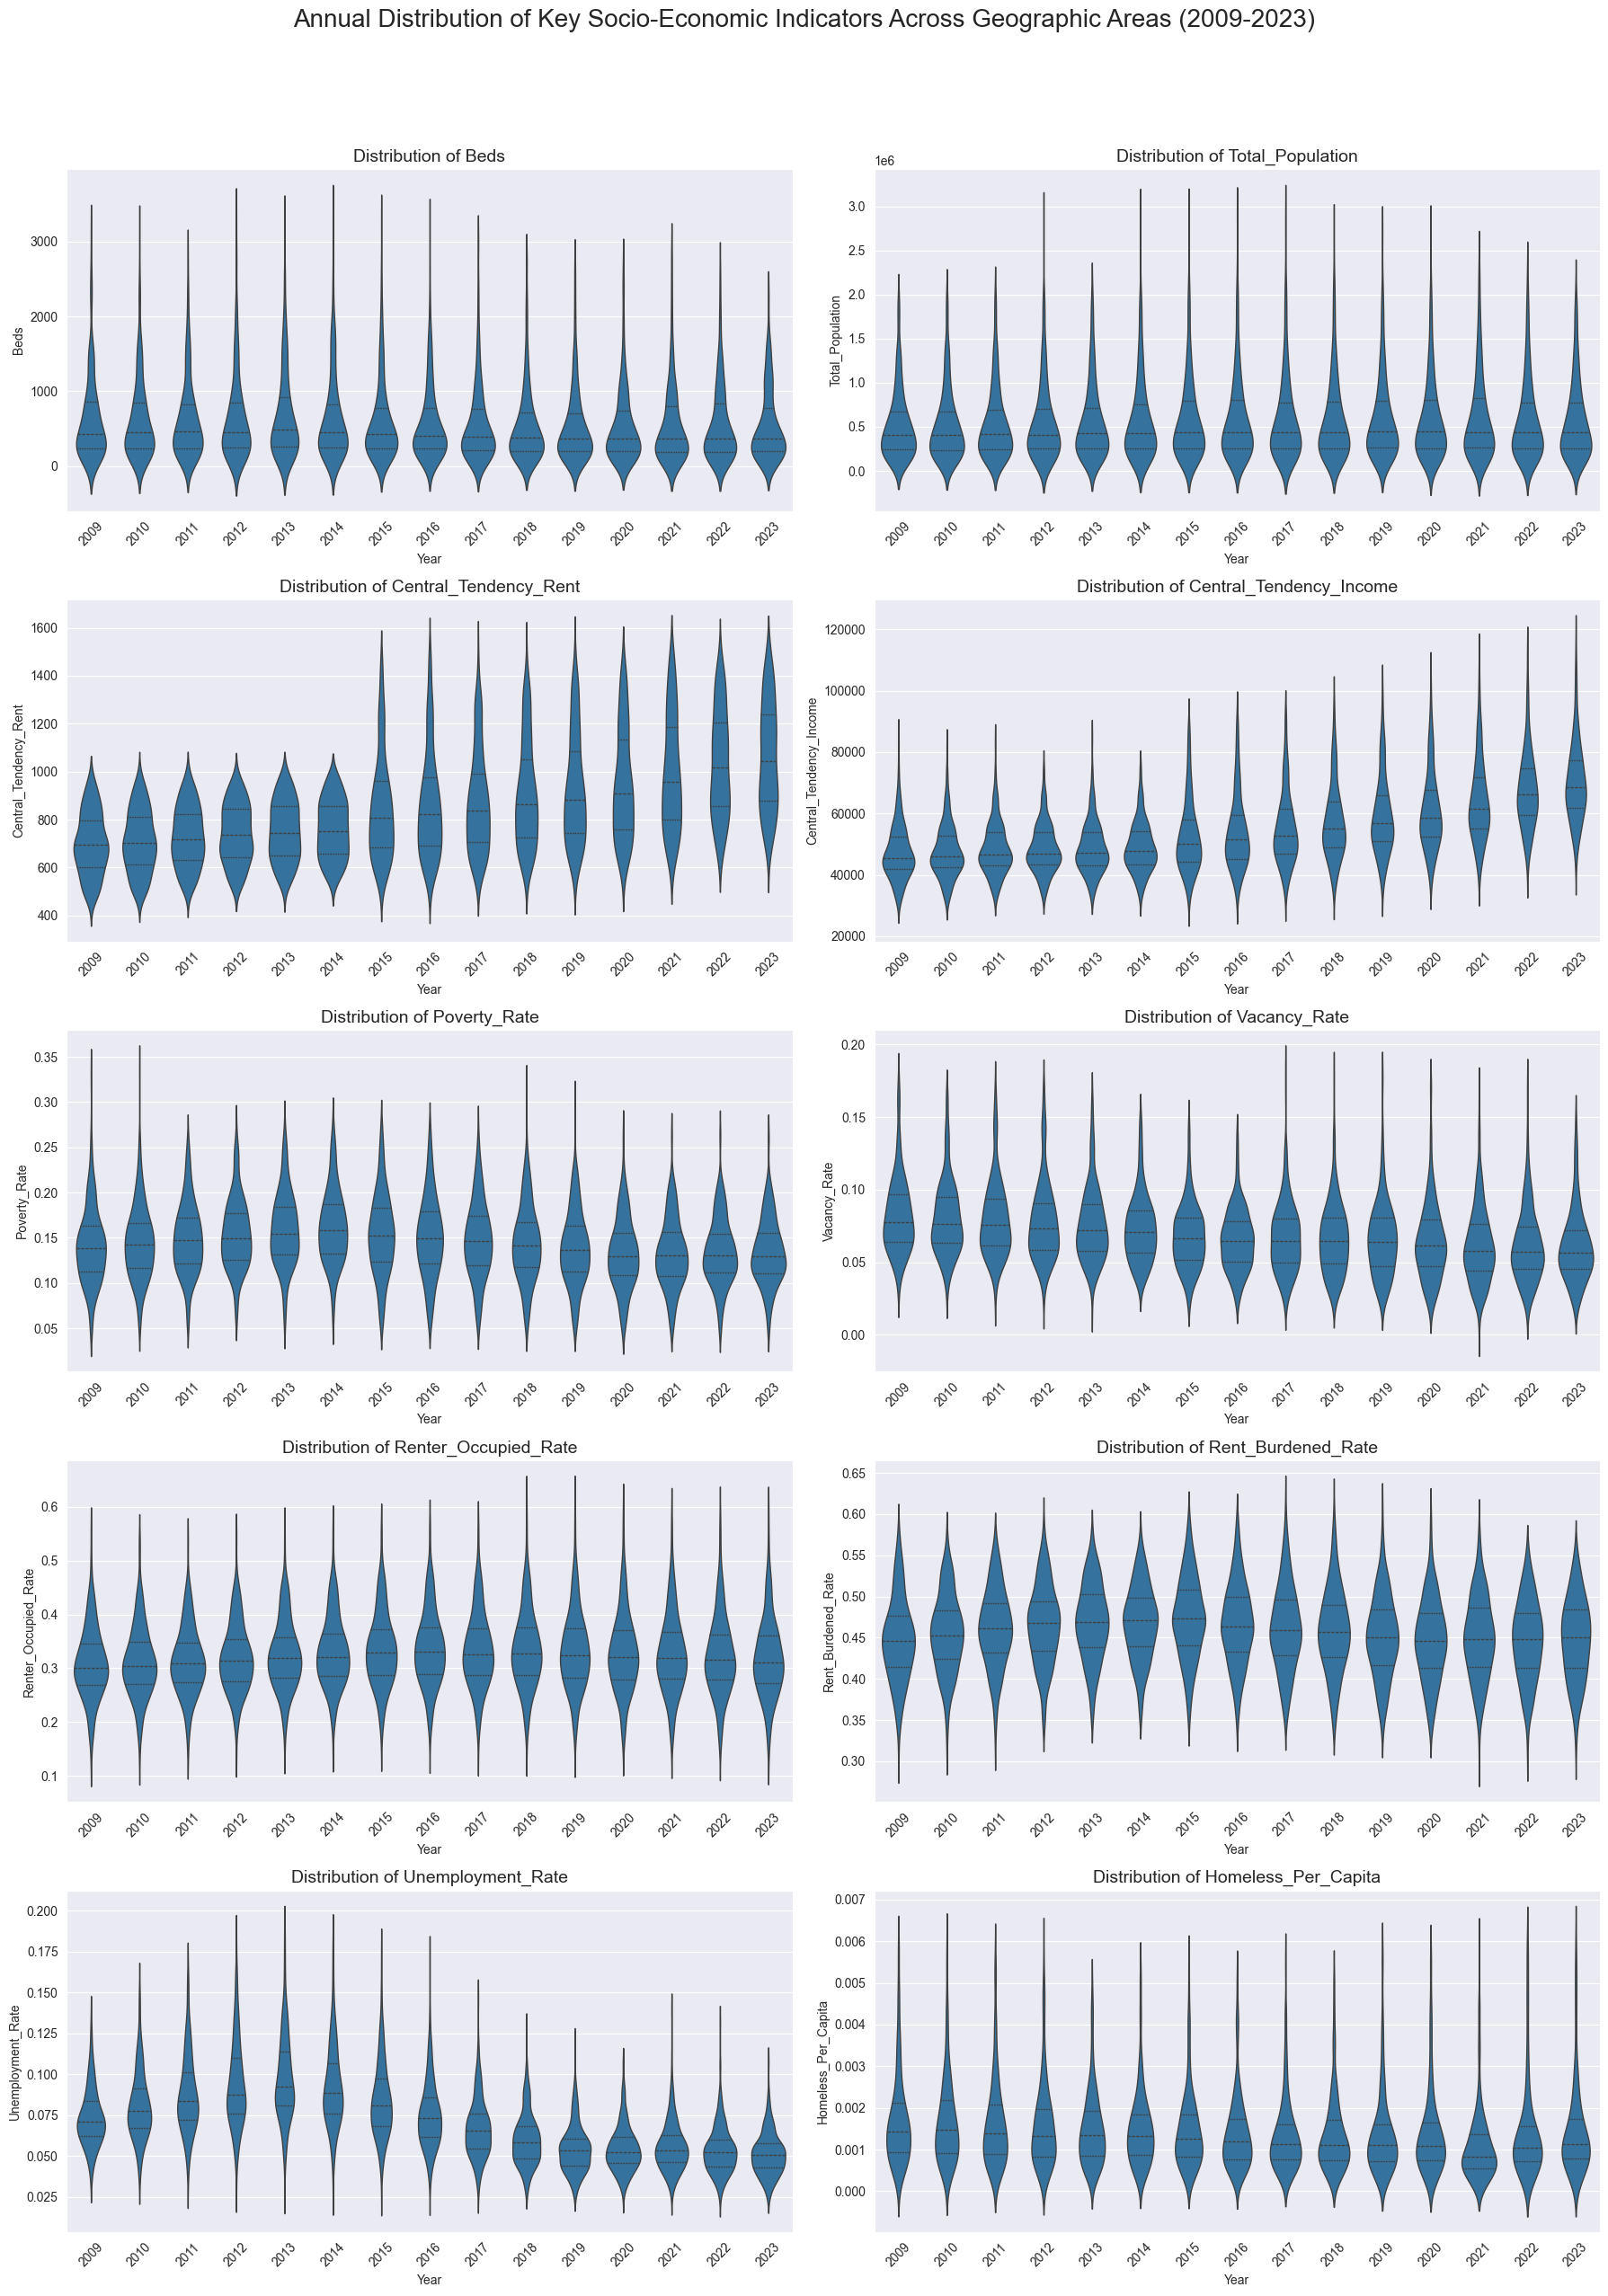

In [12]:
n_rows = 5
n_cols = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 25))
# Set the main title for the figure
fig.suptitle('Annual Distribution of Key Socio-Economic Indicators Across Geographic Areas (2009-2023)', fontsize=20, y=1.02)

axes = axes.flatten()
n_plots = len(columns_to_plot)

# Loop through the columns and plot the violin plot on the corresponding axis
for i, col in enumerate(columns_to_plot):
    # Create the Violin Plot
    sns.violinplot(
        x='year',                 # The categorical variable (15 years)
        y=col,                    # The numerical variable (the distribution to visualize)
        data=df_cleaned,
        ax=axes[i],
        inner='quartile',         # Adds lines for the median and quartiles inside the violin (Q1, Median, Q3)
        linewidth=1.0,
        saturation=0.7,
        gap=0.1
    )

    # Customize each subplot
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_xlabel('Year', fontsize=10)
    axes[i].set_ylabel(col, fontsize=10)

    # Rotate X-axis ticks for better readability of the years
    axes[i].tick_params(axis='x', rotation=45)

# Ensure tight layout to prevent titles and labels from overlapping
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to make space for subtitle

# Display the entire grid
plt.show()

# Pairwise Plot

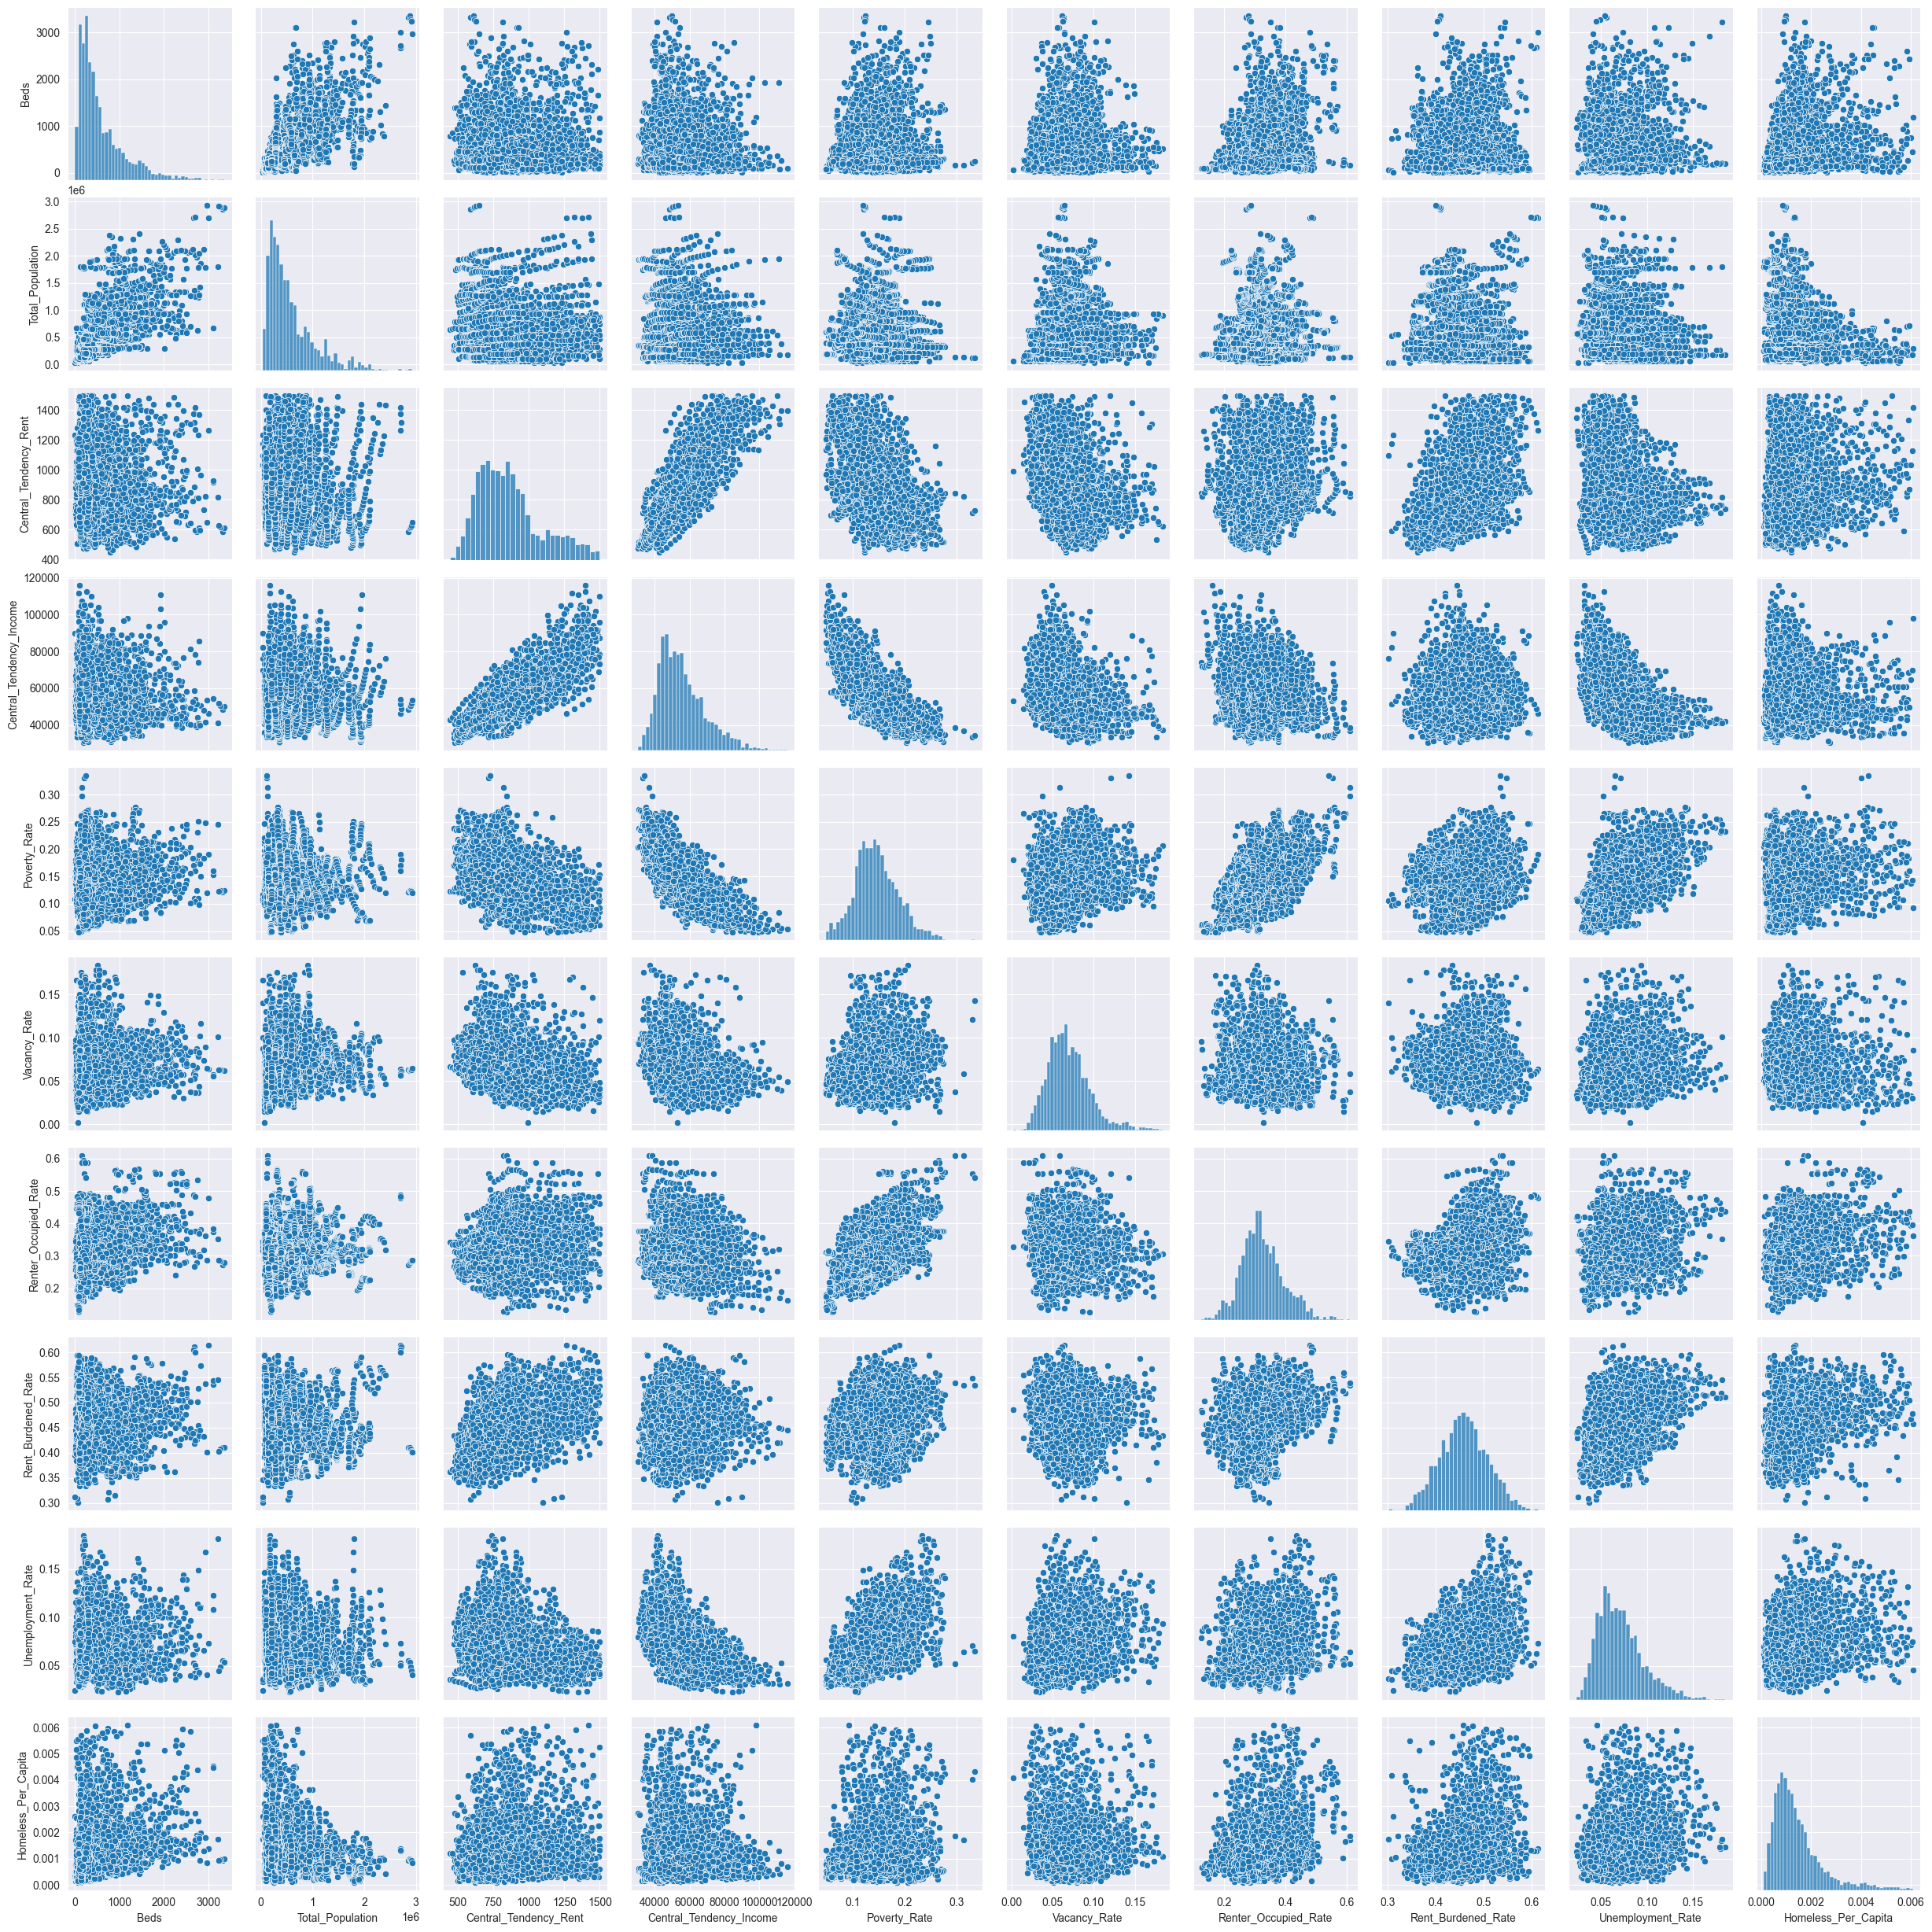

In [13]:
# Select the columns you want to visualize
df_subset = df_cleaned[columns_to_plot]

# Create the pair plot
# The diagonal (diag_kind) shows the distribution (kde for smoothness, hist for bars)
# The upper and lower triangles show the scatter plots of pairs
# Note: Pair plots for 10 columns can take some time to render!
sns.pairplot(df_subset)

# Correlation Heatmap

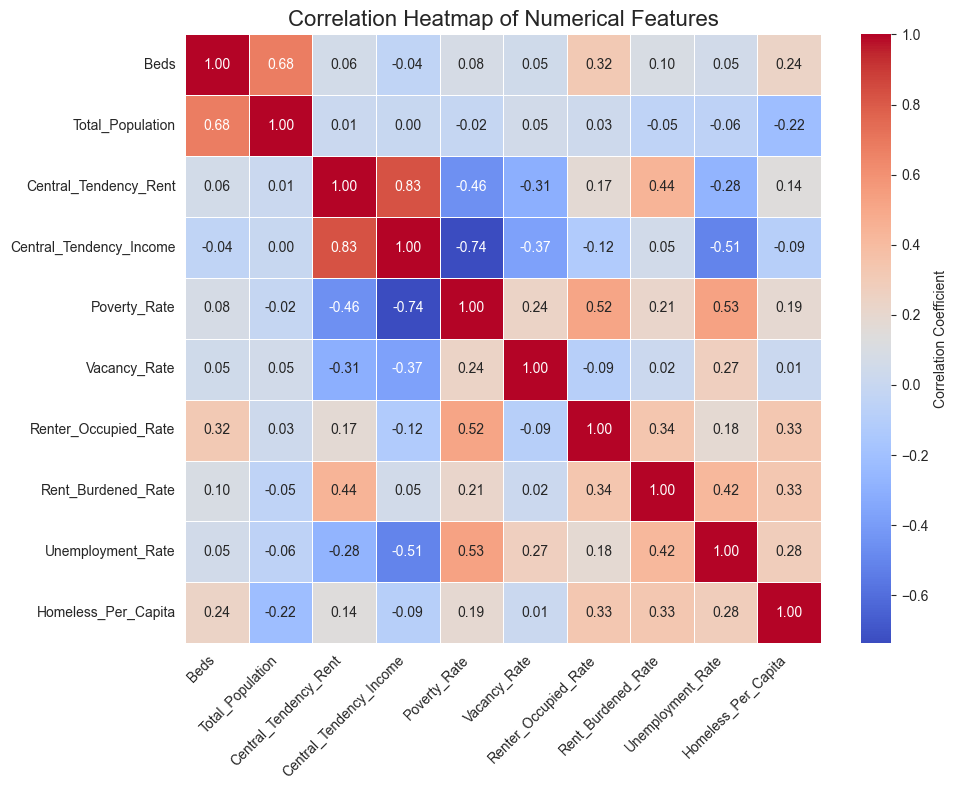

In [15]:
df_subset = df_cleaned[columns_to_plot]
corr_matrix = df_subset.corr()

plt.figure(figsize=(10, 8))

# Create the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,        # Show the correlation values on the map
    fmt=".2f",         # Format the annotations to two decimal places
    cmap='coolwarm',   # Use a diverging color map
    linewidths=.5,     # Add lines between cells for clarity
    cbar_kws={'label': 'Correlation Coefficient'}
)

# Adjust title
plt.title("Correlation Heatmap of Numerical Features", fontsize=16)

# Ensure labels are visible
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Display the plot
plt.tight_layout()
plt.show()